<a href="https://colab.research.google.com/github/nanduvarghese-glitch/gen-ai/blob/main/DAY6/CNN_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

zip_path = "/content/archive (21).zip"
extract_path = "/content/brain_tumor"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [ ]:
import os

dataset_path = "/content/brain_tumor/brain_tumor_dataset"

print(os.listdir(dataset_path))

['no', 'yes']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 583ms/step - accuracy: 0.6601 - loss: 0.6865 - val_accuracy: 0.6600 - val_loss: 0.6670
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 666ms/step - accuracy: 0.7537 - loss: 0.5301 - val_accuracy: 0.7400 - val_loss: 0.5457
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 605ms/step - accuracy: 0.8030 - loss: 0.4851 - val_accuracy: 0.7400 - val_loss: 0.5550
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 563ms/step - accuracy: 0.8227 - loss: 0.4507 - val_accuracy: 0.7400 - val_loss: 0.5422
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 659ms/step - accuracy: 0.8424 - loss: 0.4247 - val_accuracy: 0.7600 - val_loss: 0.5448
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 630ms/step - accuracy: 0.8424 - loss: 0.3659 - val_accuracy: 0.7800 - val_loss: 0.5520
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 550ms/step - accuracy: 0.8424 - loss: 0.3278 - val_accuracy: 0.7800 - val_loss: 0.4660
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 666ms/step - accuracy: 0.9113 - loss: 0.2491 - val_accuracy: 

In [ ]:
epochs=15
epochs=20

In [ ]:
loss, accuracy = model.evaluate(validation_generator)

print(f"Validation Accuracy: {accuracy*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.8400 - loss: 0.3922
Validation Accuracy: 84.00%


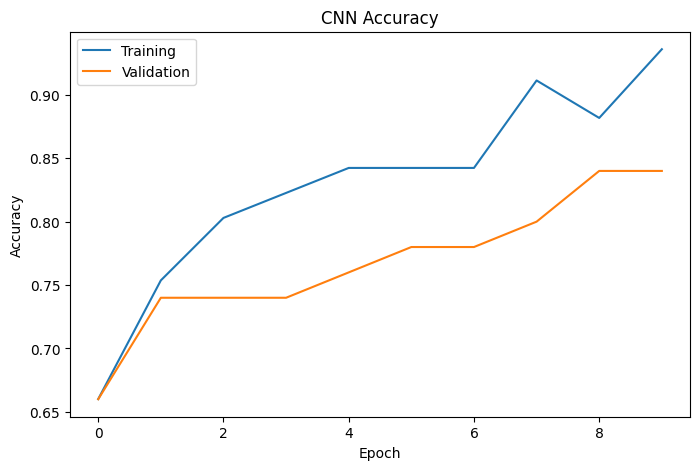

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])

plt.show()

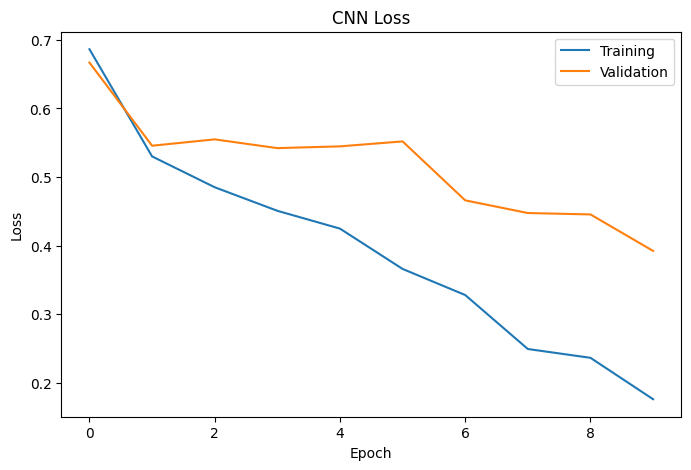

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.show()

In [ ]:
validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = (predictions > 0.5).astype(int)

y_true = validation_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 


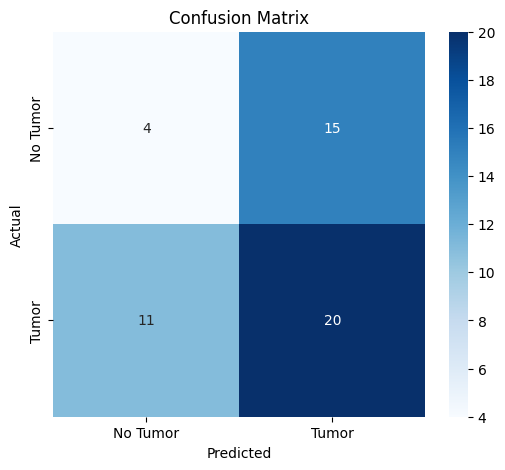

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Tumor","Tumor"],
    yticklabels=["No Tumor","Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["No Tumor","Tumor"]
    )
)

              precision    recall  f1-score   support

    No Tumor       0.27      0.21      0.24        19
       Tumor       0.57      0.65      0.61        31

    accuracy                           0.48        50
   macro avg       0.42      0.43      0.42        50
weighted avg       0.46      0.48      0.47        50



/content/4 no.jpg -> ✅ No Brain Tumor Detected
/content/Y1.jpg -> 🧠 Brain Tumor Detected
/content/5 no.jpg -> ✅ No Brain Tumor Detected
/content/Y2.jpg -> 🧠 Brain Tumor Detected


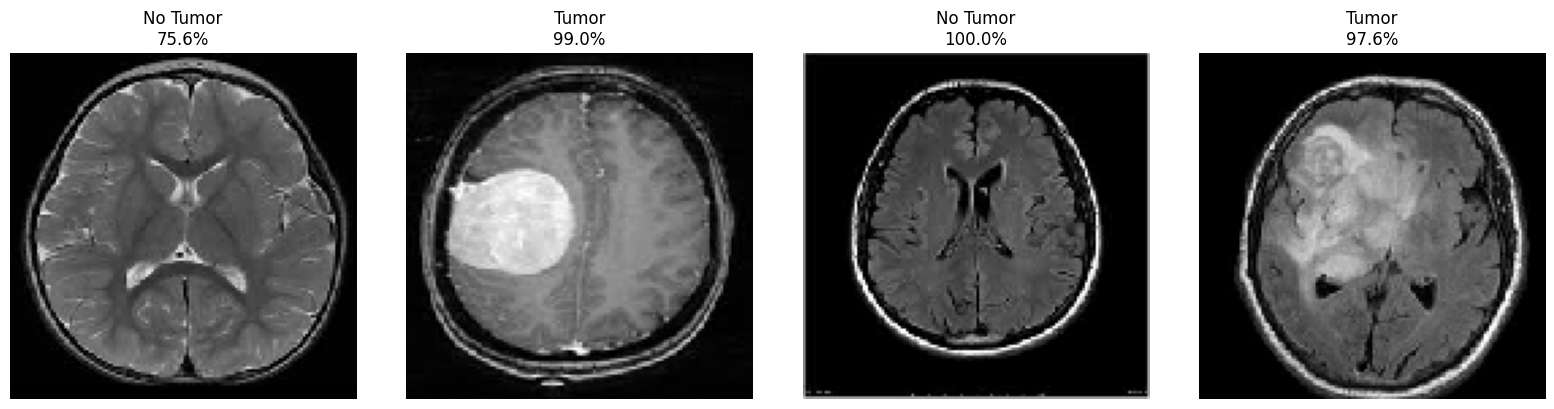

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# List of image paths
image_paths = [
    "/content/4 no.jpg",
    "/content/Y1.jpg",
    "/content/5 no.jpg",
    "/content/Y2.jpg"
]

plt.figure(figsize=(16,4))

for i, image_path in enumerate(image_paths):

    # Load image
    img = image.load_img(
        image_path,
        target_size=(128,128)
    )

    # Convert to array
    img_array = image.img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Predict
    prediction = model.predict(img_array, verbose=0)

    # Label
    if prediction[0][0] > 0.5:
        label = f"Tumor\n{prediction[0][0]*100:.1f}%"
        print(f"{image_path} -> 🧠 Brain Tumor Detected")
    else:
        label = f"No Tumor\n{(1-prediction[0][0])*100:.1f}%"
        print(f"{image_path} -> ✅ No Brain Tumor Detected")

    # Display image
    plt.subplot(1, len(image_paths), i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("brain_tumor_cnn.h5")

print("Model Saved Successfully!")

Model Saved Successfully!
